# B-mode Image Formation — Real In-vivo Carotid Artery

**Input:** real beamformed RF data from a human carotid artery (neck blood vessel), longitudinal view.
**Output:** grayscale B-mode image, sent to the Image Reconstruction / Post-processing team.

**Steps in this notebook**
1. Load RF data
2. Envelope detection (Hilbert transform)
3. Normalize
4. Log compression (dB)
5. Dynamic range (60 dB)
6. Convert to brightness (0 to 1)
7. Depth and width in mm
8. Display
9. Save output

**Data source:** in-vivo carotid data, 128-element linear probe (L12-50), 5 MHz, single plane wave.
From EPFL LTS5 public repository: github.com/LTS5/us-non-stationary-deconv
(A. Besson et al., "A Physical Model of Non-stationary Blur in Ultrasound Imaging", IEEE Trans. Computational Imaging).
Raw channel data was band-pass filtered (2–8 MHz) and beamformed with Delay-and-Sum to get the RF data.

**Files needed in the same folder:** `carotid_1_rf.npy` (or `carotid_2_rf.npy`)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert


# ==========================================
# 1. LOAD REAL RF DATA
# ==========================================

DATA_FILE = "carotid_1_rf.npy"     # change to "carotid_2_rf.npy" for the second image

rf = np.load(DATA_FILE)             # shape: (depth samples, scan lines)

print("RF data shape:", rf.shape)
print("Depth samples:", rf.shape[0])
print("Scan lines   :", rf.shape[1])
print("Minimum:", rf.min())
print("Maximum:", rf.max())

RF data shape: (1218, 128)
Depth samples: 1218
Scan lines   : 128
Minimum: -162577.23
Maximum: 166418.19


In [2]:
# ==========================================
# SAMPLING AND PROBE INFORMATION (real probe)
# ==========================================

fs = 31.25e6           # Sampling frequency = 31.25 MHz
f0 = 5e6               # Centre frequency of probe = 5 MHz
c = 1540               # Speed of sound in tissue = 1540 m/s
pitch = 0.1953e-3      # Distance between scan lines = 0.1953 mm
depth_start_mm = 5.0   # First sample is at 5 mm depth

dynamic_range = 60     # 60 dB

In [3]:
# ==========================================
# 2. ENVELOPE DETECTION (HILBERT TRANSFORM)
# ==========================================
# Hilbert transform is applied along depth (axis=0) for every scan line.
# abs() of the analytic signal gives the envelope (echo strength).

analytic_signal = hilbert(rf, axis=0)
envelope = np.abs(analytic_signal)

print("Envelope shape:", envelope.shape)
print("Minimum:", envelope.min())
print("Maximum:", envelope.max())

Envelope shape: (1218, 128)
Minimum: 4.9951687
Maximum: 170355.8


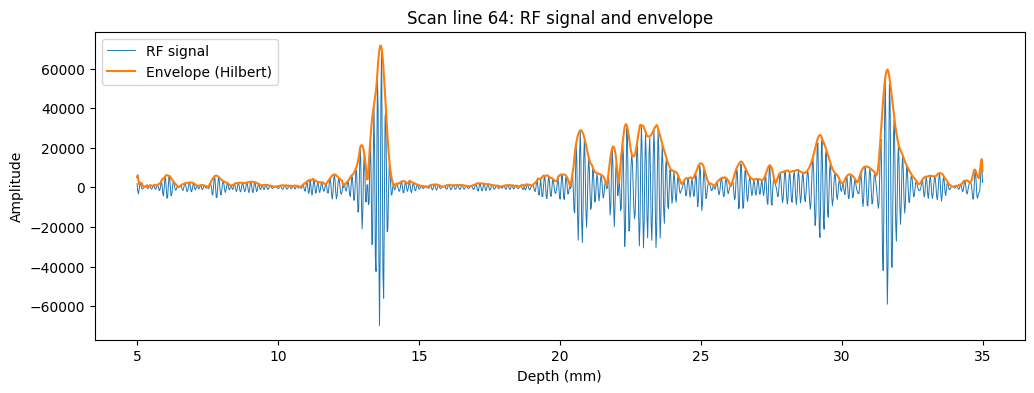

In [4]:
# ==========================================
# SHOW ONE SCAN LINE: RF SIGNAL AND ITS ENVELOPE
# ==========================================

line = rf.shape[1] // 2                     # middle scan line
depth_axis_mm = depth_start_mm + (np.arange(rf.shape[0]) / fs) * c / 2 * 1000

plt.figure(figsize=(12, 4))
plt.plot(depth_axis_mm, rf[:, line], linewidth=0.7, label="RF signal")
plt.plot(depth_axis_mm, envelope[:, line], linewidth=1.5, label="Envelope (Hilbert)")
plt.xlabel("Depth (mm)")
plt.ylabel("Amplitude")
plt.title(f"Scan line {line}: RF signal and envelope")
plt.legend()
plt.show()

In [5]:
# ==========================================
# 3. NORMALIZE ENVELOPE
# ==========================================

envelope_norm = envelope / np.max(envelope)


# ==========================================
# 4. LOG COMPRESSION (CONVERT TO dB)
# ==========================================

envelope_db = 20 * np.log10(envelope_norm + 1e-12)


# ==========================================
# 5. APPLY DYNAMIC RANGE
# ==========================================

envelope_db = np.clip(envelope_db, -dynamic_range, 0)


# ==========================================
# 6. CONVERT dB TO BRIGHTNESS (0 to 1)
# ==========================================

bmode = (envelope_db + dynamic_range) / dynamic_range

print("B-mode shape:", bmode.shape)
print("Brightness range:", bmode.min(), "to", bmode.max())

B-mode shape: (1218, 128)
Brightness range: 0.0 to 1.0


In [6]:
# ==========================================
# 7. CALCULATE DEPTH AND WIDTH (mm)
# ==========================================

num_samples, num_scanlines = rf.shape

sample_indices = np.arange(num_samples)
time = sample_indices / fs                      # time of each sample (s)
depth = (c * time) / 2                          # divide by 2: sound goes and comes back
depth_mm = depth_start_mm + depth * 1000

width_mm = (np.arange(num_scanlines) - num_scanlines / 2) * pitch * 1000

print("Depth: %.1f mm to %.1f mm" % (depth_mm[0], depth_mm[-1]))
print("Width: %.1f mm to %.1f mm" % (width_mm[0], width_mm[-1]))

extent = [width_mm[0], width_mm[-1], depth_mm[-1], depth_mm[0]]

Depth: 5.0 mm to 35.0 mm
Width: -12.5 mm to 12.3 mm


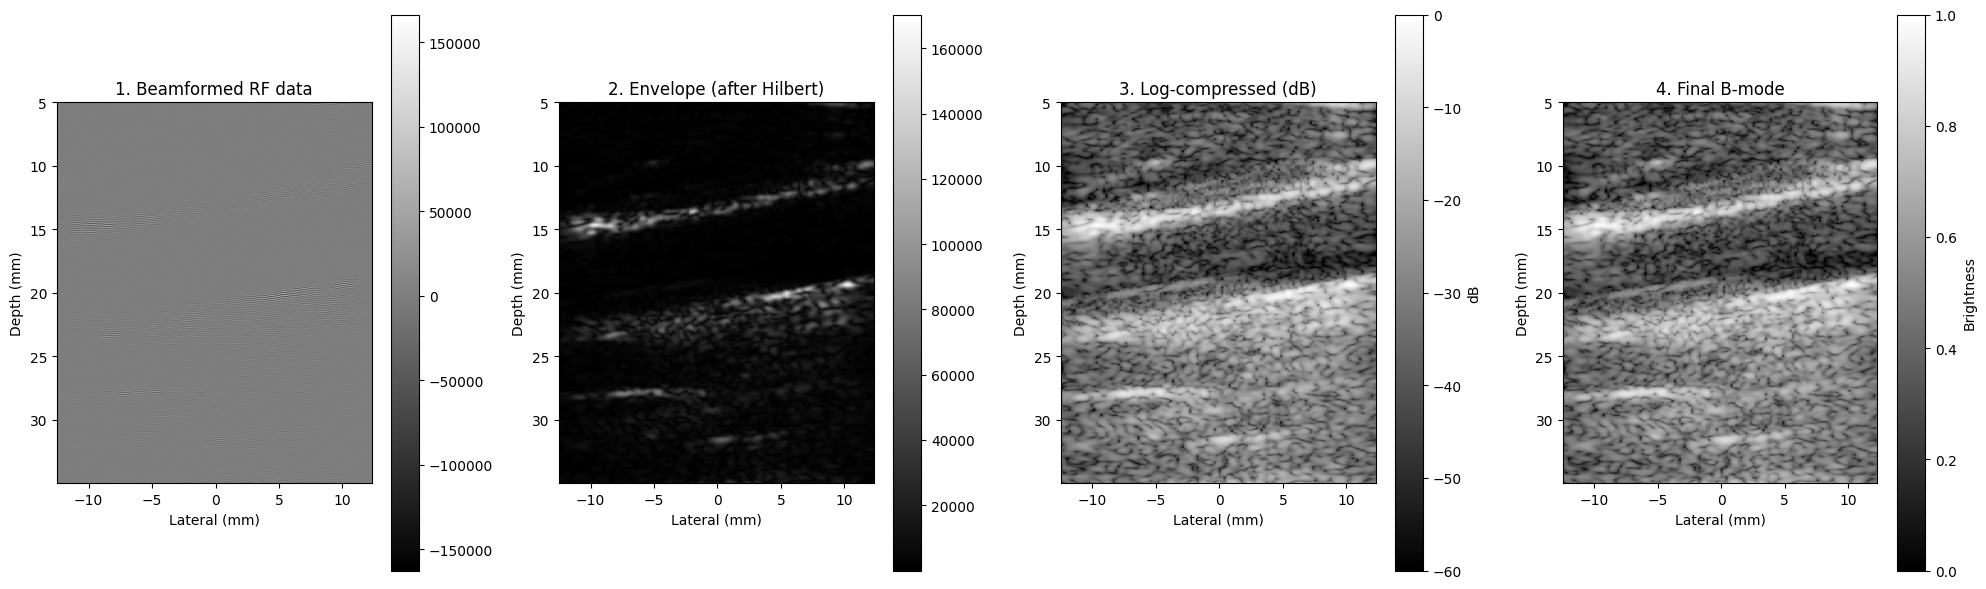

In [7]:
# ==========================================
# 8. DISPLAY ALL STEPS
# ==========================================

fig, ax = plt.subplots(1, 4, figsize=(20, 6))

im = ax[0].imshow(rf, cmap="gray", extent=extent)
ax[0].set_title("1. Beamformed RF data")
plt.colorbar(im, ax=ax[0])

im = ax[1].imshow(envelope, cmap="gray", extent=extent)
ax[1].set_title("2. Envelope (after Hilbert)")
plt.colorbar(im, ax=ax[1])

im = ax[2].imshow(envelope_db, cmap="gray", vmin=-dynamic_range, vmax=0, extent=extent)
ax[2].set_title("3. Log-compressed (dB)")
plt.colorbar(im, ax=ax[2], label="dB")

im = ax[3].imshow(bmode, cmap="gray", vmin=0, vmax=1, extent=extent)
ax[3].set_title("4. Final B-mode")
plt.colorbar(im, ax=ax[3], label="Brightness")

for a in ax:
    a.set_xlabel("Lateral (mm)")
    a.set_ylabel("Depth (mm)")

plt.tight_layout()
plt.show()

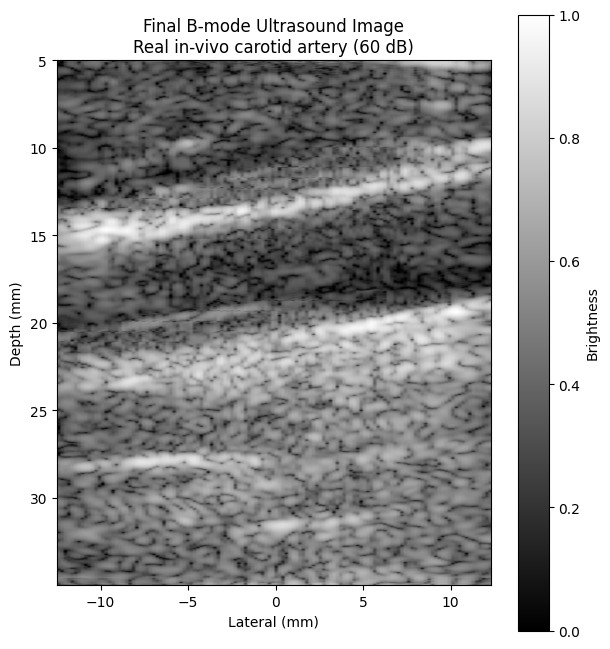

In [8]:
# ==========================================
# FINAL B-MODE IMAGE
# ==========================================

plt.figure(figsize=(7, 8))

plt.imshow(bmode, cmap="gray", vmin=0, vmax=1, extent=extent)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Final B-mode Ultrasound Image\nReal in-vivo carotid artery (60 dB)")
plt.colorbar(label="Brightness")

plt.show()

In [9]:
# ==========================================
# 9. SAVE OUTPUT FOR IMAGE RECONSTRUCTION / POST-PROCESSING TEAM
# ==========================================

name = DATA_FILE.replace("_rf.npy", "")

np.save(f"bmode_{name}.npy", bmode.astype(np.float32))              # float values 0 to 1
plt.imsave(f"bmode_{name}.png", bmode, cmap="gray", vmin=0, vmax=1)  # grayscale image
np.savez(f"bmode_{name}_axes.npz", depth_mm=depth_mm, width_mm=width_mm)

print("Saved:", f"bmode_{name}.npy", "|", f"bmode_{name}.png", "|", f"bmode_{name}_axes.npz")
print("Image size:", bmode.shape, "(depth samples x scan lines)")

Saved: bmode_carotid_1.npy | bmode_carotid_1.png | bmode_carotid_1_axes.npz
Image size: (1218, 128) (depth samples x scan lines)
